# Data preprocessing

In [4]:
from pyproj import Proj, Transformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import gdown
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler

In [5]:
!gdown --folder https://drive.google.com/drive/folders/1RZJdNpCfbMt2SB_kfWsxQgOk5LeuV7lw

Retrieving folder contents
Processing file 1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ Divar.csv
Processing file 1eX9an3tSypvrFn_fiPReYHTca5GpJaJG iran_city_classification.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ
From (redirected): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ&confirm=t&uuid=ea5dce28-bb97-4c58-9795-e2ea51392dc5
To: /home/ai-gerailo/Desktop/Divar/Divar Dataset/Divar.csv
100%|████████████████████████████████████████| 794M/794M [02:17<00:00, 5.75MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eX9an3tSypvrFn_fiPReYHTca5GpJaJG
To: /home/ai-gerailo/Desktop/Divar/Divar Dataset/iran_city_classification.csv
100%|███████████████████████████████████████| 6.16k/6.16k [00:00<00:00, 480kB/s]
Download completed


In [162]:
warnings.filterwarnings("ignore")

In [163]:
divar = pd.read_csv("Divar Dataset/Divar.csv", low_memory=True)

In [164]:
divar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  object 
 2   cat3_slug                   999999 non-null   object 
 3   city_slug                   999998 non-null   object 
 4   neighborhood_slug           437139 non-null   object 
 5   created_at_month            1000000 non-null  object 
 6   user_type                   288882 non-null   object 
 7   description                 1000000 non-null  object 
 8   title                       999946 non-null   object 
 9   rent_mode                   352994 non-null   object 
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   object 
 13

### 1. We will remove "real-estate-services"
---
Since, there isn't enough information for these types of advertisements we'll drop this data.

In [165]:
divar["cat2_slug"].unique()

array(['temporary-rent', 'residential-sell', 'residential-rent',
       'commercial-rent', 'commercial-sell', 'real-estate-services'],
      dtype=object)

In [166]:
# There is no helpful data for these estates to help the model recognize them. It just confiusion --> drop
divar[divar["cat2_slug"]=="real-estate-services"].info()

<class 'pandas.core.frame.DataFrame'>
Index: 19403 entries, 125 to 999994
Data columns (total 61 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  19403 non-null  int64  
 1   cat2_slug                   19403 non-null  object 
 2   cat3_slug                   19403 non-null  object 
 3   city_slug                   19403 non-null  object 
 4   neighborhood_slug           8611 non-null   object 
 5   created_at_month            19403 non-null  object 
 6   user_type                   6530 non-null   object 
 7   description                 19403 non-null  object 
 8   title                       19402 non-null  object 
 9   rent_mode                   2 non-null      object 
 10  rent_value                  2 non-null      float64
 11  rent_to_single              0 non-null      object 
 12  rent_type                   2 non-null      object 
 13  price_mode                  1220 

In [167]:
divar = divar[divar["cat2_slug"] != "real-estate-services"] # we'll drop ~20000 confiusing data

### 2. Dropping unimportant features
---
It is important to be decided which columns must be dropped to **manage memory**.

In [168]:
rm_cols = ["neighborhood_slug", "created_at_month", "user_type",
           "rent_mode", "rent_to_single", "price_mode",
           "credit_mode", "unit_per_floor", "rent_type", "unit_per_floor", "has_water",
           "has_electricity", "has_gas", "Unnamed: 0", "location_radius",
           "has_restroom", "floor_material", "property_type", "land_size",
           "title", "description", "building_direction", "regular_person_capacity", "extra_person_capacity"]

divar.drop(columns=rm_cols, inplace=True)

In [169]:
divar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980597 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   cat2_slug                   980597 non-null  object 
 1   cat3_slug                   980596 non-null  object 
 2   city_slug                   980595 non-null  object 
 3   rent_value                  351320 non-null  float64
 4   price_value                 567136 non-null  float64
 5   credit_value                352093 non-null  float64
 6   rent_credit_transform       352985 non-null  object 
 7   transformable_price         352894 non-null  object 
 8   transformable_credit        352085 non-null  float64
 9   transformed_credit          72409 non-null   float64
 10  transformable_rent          351248 non-null  float64
 11  transformed_rent            72409 non-null   float64
 12  building_size               980388 non-null  float64
 13  deed_type          

### 3. Features: cat2_slug, cat3_slug
---
Before categorizing them there is only one null value that I manually checked its description and it was about office-rent</br>
Then we'll encode it with label encodel

In [170]:
print(divar["cat2_slug"].unique())
print("="*30)
print(divar["cat3_slug"].unique())
print("="*30)
print(divar.groupby("cat2_slug")["cat3_slug"].unique())

['temporary-rent' 'residential-sell' 'residential-rent' 'commercial-rent'
 'commercial-sell']
['villa' 'apartment-sell' 'apartment-rent' 'office-rent' 'shop-sell'
 'plot-old' 'house-villa-sell' 'house-villa-rent' 'shop-rent'
 'industry-agriculture-business-rent' 'office-sell'
 'industry-agriculture-business-sell' 'suite-apartment' 'workspace' nan]
cat2_slug
commercial-rent     [office-rent, shop-rent, industry-agriculture-...
commercial-sell     [shop-sell, office-sell, industry-agriculture-...
residential-rent                   [apartment-rent, house-villa-rent]
residential-sell         [apartment-sell, plot-old, house-villa-sell]
temporary-rent                    [villa, suite-apartment, workspace]
Name: cat3_slug, dtype: object


In [171]:
# Handling missing value
cat3_null_idx = divar[divar["cat3_slug"].isnull()].index
divar.loc[cat3_null_idx, "cat3_slug"] = "office-rent"

In [172]:
# Merging cat2 + cat3`
divar = divar.dropna(subset=["cat3_slug"])
divar.insert(0, "category", 
             divar.apply(lambda row: f"{row['cat2_slug']}_{row['cat3_slug']}", axis=1))
divar.drop(columns=["cat2_slug", "cat3_slug"], inplace=True)

In [173]:
divar["category"].unique()

array(['temporary-rent_villa', 'residential-sell_apartment-sell',
       'residential-rent_apartment-rent', 'commercial-rent_office-rent',
       'commercial-sell_shop-sell', 'residential-sell_plot-old',
       'residential-sell_house-villa-sell',
       'residential-rent_house-villa-rent', 'commercial-rent_shop-rent',
       'commercial-rent_industry-agriculture-business-rent',
       'commercial-sell_office-sell',
       'commercial-sell_industry-agriculture-business-sell',
       'temporary-rent_suite-apartment', 'temporary-rent_workspace'],
      dtype=object)

### 4. Specifying target column - price

In [174]:
def create_target_price(divar):
    
    monthly_rent_to_sale_factor=200          # 20,000,000 rent * 200 = 4,000,000,000 price for sale
    credit_rent_factor=33.33                 # (20,000,000 rent * 33.33) + 200,000,000 credit * 5 = 4,333,000,000 price
    weekend_to_month= 8                      # 8 weekends/month * 7,000,000 *200 = 11,200,000 price
    credit_to_sale = 5                       # 1,000,000,000 credit * 5 = 5,000,000,000 price for sale
    day_to_month = 30                        # 1,000,000 rent/day *30 *200 = 6,000,000,000 price for sale

    df_target = divar.copy()
    df_target['target_price'] = np.nan
    
    # numrical columns that should be numeric
    numeric_columns = ['price_value','transformable_price','credit_value','rent_value','transformable_credit','rent_price_on_regular_days']
    
    # Convert numeric columns to numbers (invalid values → NaN)
    for col in numeric_columns:
        if col in df_target.columns:
            df_target[col] = pd.to_numeric(df_target[col], errors='coerce')
    

    # temporary rent ads
    df_target['is_temporary'] = df_target['category'].astype(str).str.contains('temporary-', na=False)
    # sell ads
    df_target['is_sell'] = df_target['category'].astype(str).str.contains('-sell', na=False)
    # normal rent ads (exclude temporary rent)
    df_target['is_rent'] = (df_target['category'].astype(str).str.contains('-rent', na=False)& ~df_target['is_temporary'])
    
    
    # 1. sell ads
    # direct sell price
    sell_mask = df_target['is_sell'] & df_target['price_value'].notna()
    df_target.loc[sell_mask, 'target_price'] = df_target.loc[sell_mask, 'price_value']
    # use transformable price if available
    transformable_mask = (df_target['transformable_price'].notna() & (df_target['transformable_price'] > 0) & df_target['target_price'].isna())
    df_target.loc[transformable_mask, 'target_price'] = df_target.loc[transformable_mask, 'transformable_price']
    
    
    # 2. normal rent ads (rahn + ejare)
    rent_mask = (df_target['is_rent'] & ~df_target['is_temporary'] & df_target['target_price'].isna())
    # both deposit and rent exist
    mask_both = rent_mask & df_target['credit_value'].notna() & df_target['rent_value'].notna()
    df_target.loc[mask_both, 'target_price'] = ((df_target.loc[mask_both, 'credit_value'] + df_target.loc[mask_both, 'rent_value'] * credit_rent_factor)* credit_to_sale)
    # only credit exists
    mask_credit_only = rent_mask & df_target['credit_value'].notna() & df_target['rent_value'].isna()
    df_target.loc[mask_credit_only, 'target_price'] = (df_target.loc[mask_credit_only, 'credit_value'] * credit_to_sale)
    # only rent exists
    mask_rent_only = rent_mask & df_target['rent_value'].notna() & df_target['credit_value'].isna()
    df_target.loc[mask_rent_only, 'target_price'] = (df_target.loc[mask_rent_only, 'rent_value'] * monthly_rent_to_sale_factor)
    
    
    # 3. Temporary rent ads
    temp_mask = df_target['is_temporary'] & df_target['target_price'].isna()
    # Use regular day price first
    if 'rent_price_on_regular_days' in df_target.columns:
        mask_temp_regular = temp_mask & df_target['rent_price_on_regular_days'].notna()
        monthly_rent = df_target.loc[mask_temp_regular, 'rent_price_on_regular_days'] * day_to_month
        df_target.loc[mask_temp_regular, 'target_price'] = (monthly_rent * monthly_rent_to_sale_factor)
    
    # If regular price not available, use weekend price
    if 'rent_price_at_weekends' in df_target.columns:
        mask_temp_weekend = (temp_mask & df_target['target_price'].isna() & df_target['rent_price_at_weekends'].notna())
        monthly_rent = df_target.loc[mask_temp_weekend, 'rent_price_at_weekends'] * weekend_to_month
        df_target.loc[mask_temp_weekend, 'target_price'] = (monthly_rent * monthly_rent_to_sale_factor)
    
    
    # 4. transformable credit
    missing_mask = df_target['target_price'].isna() & df_target['transformable_credit'].notna()
    df_target.loc[missing_mask, 'target_price'] = df_target.loc[missing_mask, 'transformable_credit']
    
    
    df_target['price_source'] = 'unknown'
    df_target.loc[sell_mask, 'price_source'] = 'direct_sell'
    df_target.loc[transformable_mask, 'price_source'] = 'transformable'
    df_target.loc[mask_both, 'price_source'] = 'rent_credit_both'
    df_target.loc[mask_temp_regular, 'price_source'] = 'temporary_regular'
    
    return df_target

In [175]:
divar = create_target_price(divar)

In [176]:
divar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980597 entries, 0 to 999999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   category                    980597 non-null  object 
 1   city_slug                   980595 non-null  object 
 2   rent_value                  351320 non-null  float64
 3   price_value                 567136 non-null  float64
 4   credit_value                352093 non-null  float64
 5   rent_credit_transform       352985 non-null  object 
 6   transformable_price         352894 non-null  float64
 7   transformable_credit        352085 non-null  float64
 8   transformed_credit          72409 non-null   float64
 9   transformable_rent          351248 non-null  float64
 10  transformed_rent            72409 non-null   float64
 11  building_size               980388 non-null  float64
 12  deed_type                   253458 non-null  object 
 13  has_business_deed  

### 5. Splitting data to avoid **Data leakage**

In [177]:
train_df, test_df = train_test_split(divar, test_size=0.2, random_state=42)

For these data there is no price in any kind. we can drop or impute. I prefer to impute to save data.

### 6. Checking null prices ~34406 data

In [178]:
train_df[train_df["target_price"].isnull()][["rent_value", "price_value", "credit_value", "rent_credit_transform", "transformable_price",
                                            "transformable_credit", "transformed_credit", "transformable_rent", "transformed_rent",
                                            "rent_price_on_regular_days", "rent_price_at_weekends"]]

,rent_value,price_value,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,rent_price_on_regular_days,rent_price_at_weekends
74398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
611437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513125,NaN,NaN,NaN,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN
859748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
440481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
136406,NaN,NaN,NaN,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN
591376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
692297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
679197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 7. Imputing target price 
---
Based on the median of ads types + global median for the rest

In [179]:
def impute_target_price_by_source(train_df, test_df):

    # Compute median target price per source
    source_median = (train_df.groupby('price_source')['target_price'].median())

    # Fill missing values in train
    train_df['target_price'] = train_df['target_price'].fillna(train_df['price_source'].map(source_median))
    # Fill missing values in test using train medians
    test_df['target_price'] = test_df['target_price'].fillna(test_df['price_source'].map(source_median))

    # if source not seen in train
    global_median = train_df['target_price'].median()
    # median for train will be used for test
    train_df['target_price'] = train_df['target_price'].fillna(global_median)
    test_df['target_price'] = test_df['target_price'].fillna(global_median)

    return train_df, test_df

In [180]:
# we imputed separately to avoid data leakage
train_df, test_df = impute_target_price_by_source(train_df, test_df)

In [183]:
lower_bound = train_df['target_price'].quantile(0.05)
upper_bound = train_df['target_price'].quantile(0.95)

train_df = train_df[(train_df['target_price'] > lower_bound) & (train_df['target_price'] < upper_bound)]
test_df = test_df[(test_df['target_price'] > lower_bound) & (test_df['target_price'] < upper_bound)]

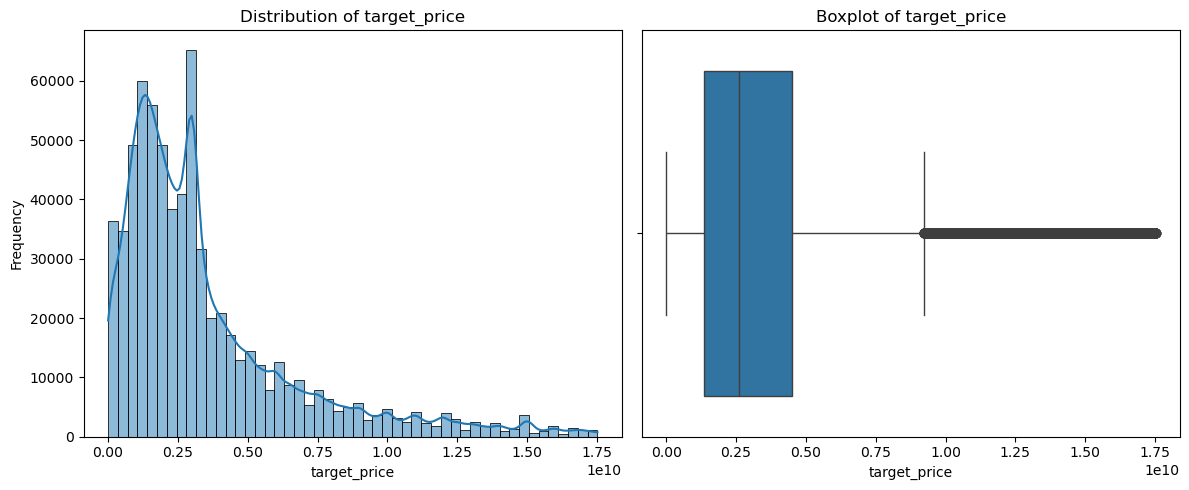

In [184]:
# For target price
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)  
sns.histplot(train_df["target_price"], bins=50, kde=True)
plt.title('Distribution of target_price')
plt.xlabel('target_price')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train_df["target_price"])
plt.title('Boxplot of target_price')

plt.tight_layout()
plt.show()

In [185]:
# create log version of target price (for ML model)
train_df['log_target_price'] = np.log1p(train_df['target_price'])
test_df['log_target_price'] = np.log1p(test_df['target_price'])

### 8. Dropping ads with 0 price by users
---
maybe these ads are because of the undetermined price to negotiate with the customer

In [186]:
train_df[train_df["target_price"] == 0]

,category,city_slug,rent_value,price_value,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,...,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,target_price,is_temporary,is_sell,is_rent,price_source,log_target_price


In [187]:
# some users set 0 value for price! we'll remove it
train_df = train_df[train_df["target_price"] != 0]
test_df = test_df[test_df["target_price"] != 0]

### 9. Unnecessary price columns

In [188]:
# Now lets drop additional features for price
rm_cols_price = ["rent_value", "price_value", "credit_value", "rent_credit_transform", "transformable_price",
                 "transformable_credit", "transformed_credit", "transformable_rent", "transformed_rent",
                 "rent_price_on_regular_days", "rent_price_at_weekends", "is_rent", "is_sell", "is_temporary",
                "price_source", "target_price"]
train_df.drop(columns=rm_cols_price, inplace=True)
test_df.drop(columns=rm_cols_price, inplace=True)

In [189]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 684678 entries, 499377 to 124368
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   category                    684678 non-null  object 
 1   city_slug                   684677 non-null  object 
 2   building_size               684507 non-null  float64
 3   deed_type                   190907 non-null  object 
 4   has_business_deed           24799 non-null   object 
 5   floor                       366673 non-null  object 
 6   rooms_count                 583223 non-null  object 
 7   total_floors_count          204889 non-null  object 
 8   has_balcony                 349153 non-null  object 
 9   has_elevator                366674 non-null  object 
 10  has_warehouse               500366 non-null  object 
 11  has_parking                 500367 non-null  object 
 12  construction_year           560648 non-null  object 
 13  is_rebuilt    

In [190]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171346 entries, 99359 to 692147
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   category                    171346 non-null  object 
 1   city_slug                   171346 non-null  object 
 2   building_size               171309 non-null  float64
 3   deed_type                   47602 non-null   object 
 4   has_business_deed           6128 non-null    object 
 5   floor                       91357 non-null   object 
 6   rooms_count                 145778 non-null  object 
 7   total_floors_count          50986 non-null   object 
 8   has_balcony                 87467 non-null   object 
 9   has_elevator                91357 non-null   object 
 10  has_warehouse               125272 non-null  object 
 11  has_parking                 125272 non-null  object 
 12  construction_year           140210 non-null  object 
 13  is_rebuilt     

### 10. Category feature encoding

In [191]:
le = LabelEncoder()
divar["category"] = le.fit_transform(divar["category"])

### 11. Feature: city_slug
---
there were only two null values that based on users' descriptions I'll fill it manually

In [192]:
train_city_null_idx = train_df[train_df['city_slug'].isnull() == True].index
test_city_null_idx = test_df[test_df['city_slug'].isnull() == True].index

In [193]:
print(f"city nulls in train_df: {train_city_null_idx}")
print(f"city nulls in test_df: {test_city_null_idx}")

city nulls in train_df: Index([292674], dtype='int64')
city nulls in test_df: Index([], dtype='int64')


In [194]:
train_df.loc[train_city_null_idx[0], "city_slug"] = "rasht" # I checked their descriptions before
train_df.loc[train_city_null_idx[-1], "city_slug"] = "shiraz"

In [195]:
# encoding
divar["city_slug"] = le.fit_transform(divar["city_slug"])

### 12. Features: bulding_size
---
- Why? building_size defines an important fearure, helping distinguishing between various estates 
- Missing Value? I filled them with the median of each category then used the total median for the remained null values.

In [196]:
# only 0.02% null! we can drop or impute --> I'll impute with the median
train_df["building_size"].isnull().sum()/train_df["building_size"].shape[0] * 100

np.float64(0.024975243837249042)

In [197]:
def impute_building_size(train_df, test_df):

    # median per category in train
    medians = train_df.groupby("category")["building_size"].median()

    # fill null in train
    train_df["building_size"] = train_df.apply(lambda row: medians[row["category"]] if pd.isna(row["building_size"]) else row["building_size"], axis=1)
    # fill nulls in test using same train medians
    test_df["building_size"] = test_df.apply(lambda row: medians[row["category"]] if pd.isna(row["building_size"]) else row["building_size"], axis=1)

    return train_df, test_df

In [198]:
# we imputed separately to avoid data leakage
train_df, test_df = impute_building_size(train_df, test_df)

In [199]:
test_nulls = test_df["building_size"].isnull().sum()
train_nulls = train_df["building_size"].isnull().sum()
print(f"Number of remained nulls in train: {train_nulls}")
print(f"Number of remained nulls in test: {test_nulls}")

Number of remained nulls in train: 0
Number of remained nulls in test: 0


let's checking the situation of values for buildings size

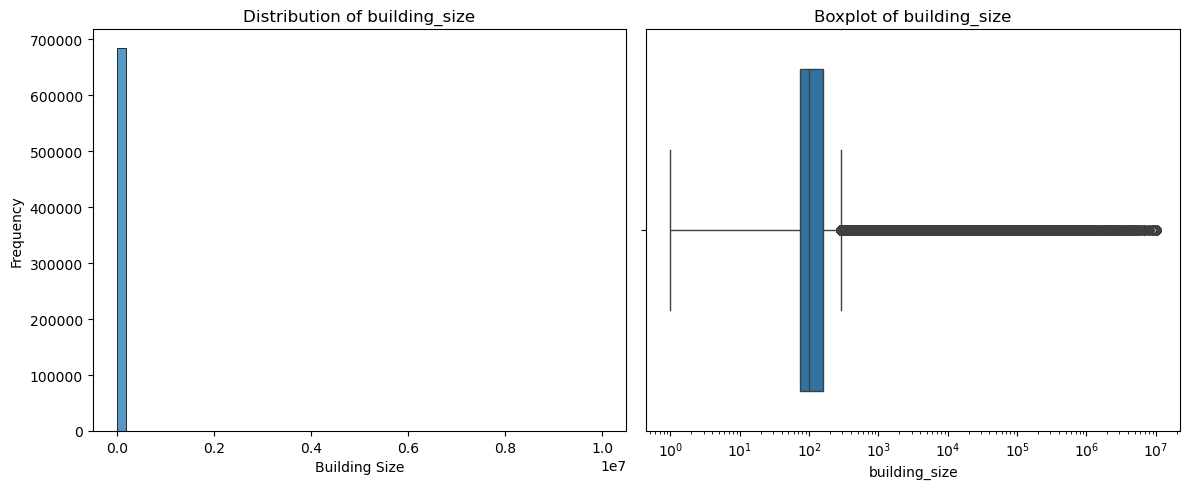

In [200]:
# Very Skewed
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)  
sns.histplot(train_df["building_size"], bins=50)
plt.title('Distribution of building_size')
plt.xlabel('Building Size')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train_df["building_size"])
plt.title('Boxplot of building_size')
plt.xscale('log')

plt.tight_layout()
plt.show()

This big interval for sizes are because of small rooms around 50 meter to 10000... for farms</br>
we cannot destroy data for big farms and lands --> I'll drop very noisy values above 0.99 and under 0.01

In [201]:
train_df["building_size"].min()

1.0

In [202]:
train_df["building_size"].max()

10000000.0

In [203]:
train_df["building_size"].describe()

count    6.846780e+05
mean     4.363319e+03
std      1.389858e+05
min      1.000000e+00
25%      7.400000e+01
50%      1.000000e+02
75%      1.600000e+02
max      1.000000e+07
Name: building_size, dtype: float64

In [204]:
train_df['building_size'] = pd.to_numeric(train_df['building_size'], errors='coerce')
test_df['building_size'] = pd.to_numeric(test_df['building_size'], errors='coerce')

# drop sizes < 0 (not valid)
train_df['building_size'] = train_df['building_size'].clip(lower=1)
test_df['building_size'] = test_df['building_size'].clip(lower=1)

lower_bound = train_df['building_size'].quantile(0.1)
upper_bound = train_df['building_size'].quantile(0.9)

train_df['building_size'] = train_df['building_size'].clip(lower=lower_bound, upper=upper_bound)
test_df['building_size'] = test_df['building_size'].clip(lower=lower_bound, upper=upper_bound)

# لگاریتم برای کاهش اثر outlier
scaler = RobustScaler()
train_df['building_size'] = np.log1p(train_df['building_size'])
test_df['building_size'] = np.log1p(test_df['building_size'])

train_df['building_size'] = scaler.fit_transform(train_df[['building_size']])
test_df['building_size'] = scaler.transform(test_df[['building_size']])

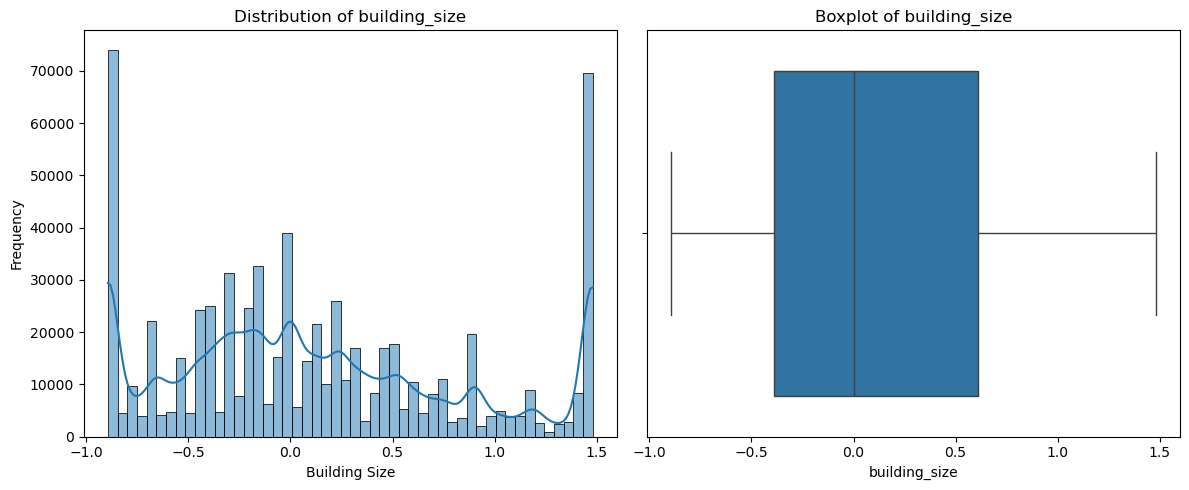

In [205]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)  
sns.histplot(train_df["building_size"], bins=50, kde=True)
plt.title('Distribution of building_size')
plt.xlabel('Building Size')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train_df["building_size"])
plt.title('Boxplot of building_size')

plt.tight_layout()
plt.show()

### 13. Features: Deed_type:
----
- Decision: **KEEP it**
- Why? This feature helps to distinguishe between properties for sale and rent
- Missing Value? if it is nan means unselcted
- Encoder? label encoder

In [206]:
# Deed_type --> the nan value = unselected
divar["deed_type"].unique()

array([nan, 'single_page', 'other', 'written_agreement', 'multi_page',
       'unselect'], dtype=object)

In [207]:
train_df["deed_type"] = train_df["deed_type"].fillna("unselect")
test_df["deed_type"] = test_df["deed_type"].fillna("unselect")

train_df["deed_type"] = le.fit_transform(train_df["deed_type"])
test_df["deed_type"] = le.transform(test_df["deed_type"])

### 14. Features: has_business_deed
----
- Decision: **KEEP it**
- Why? This feature helps to distinguishe between properties for sale and rent
- Missing Value? if it is nan means unselcted
- Encoder? label encoder

In [208]:
divar["has_business_deed"].unique()

array([nan, False, True], dtype=object)

In [209]:
train_df["has_business_deed"] = train_df["has_business_deed"].fillna(False)
test_df["has_business_deed"] = test_df["has_business_deed"].fillna(False)

train_df["has_business_deed"] = le.fit_transform(train_df["has_business_deed"])
test_df["has_business_deed"] = le.transform(test_df["has_business_deed"])

### 15.  Features: Luxury_features = has_security_guard + has_pool + has_jacuzzi + has_sauna + has_barbecue

In [210]:
luxury_feature_cols = ['has_security_guard', 'has_pool', 'has_jacuzzi', 'has_sauna', 'has_barbecue']

for col in luxury_feature_cols:
    train_df[col] = (train_df[col].fillna('False').map({'True': 1, 'False': 0}))
    test_df[col] = (test_df[col].fillna('False').map({'True': 1, 'False': 0}))
    
train_df['luxury_features'] = train_df[luxury_feature_cols].sum(axis=1)
test_df['luxury_features'] = test_df[luxury_feature_cols].sum(axis=1)

train_df.drop(columns=luxury_feature_cols, inplace=True)
test_df.drop(columns=luxury_feature_cols, inplace=True)

### 16. Features: Basic_features_cols = has_balcony + has_warehouse + has_parking + has_cooling_system + has_heating_system

In [ ]:
train_df["has_balcony"] = (train_df["has_balcony"].replace({True: 'true', False: 'false','True': 'true','False': 'false','true': 'true','false': 'false','unselect': 'false'}).fillna('false'))
train_df["has_cooling_system"] = (train_df["has_cooling_system"].replace({"air_conditioner": 'true', "water_cooler": 'true','unselect': 'false','duct_split': 'true','split': 'true','fan_coil': 'true'}).fillna('false'))
train_df["has_heating_system"] = (train_df["has_heating_system"].replace({"shoofaj": 'true', "heater": 'true','unselect': 'false','duct_split': 'true','split': 'true','fireplace': 'true', 'floor_heating':'true', 'fan_coil':'true'}).fillna('false'))
train_df["has_warm_water_provider"] = (train_df["has_warm_water_provider"].replace({"package": 'true', "water_heater": 'true','unselect': 'false','powerhouse': 'true'}).fillna('false'))

In [ ]:
test_df["has_balcony"] = (test_df["has_balcony"].replace({True: 'true', False: 'false','True': 'true','False': 'false','true': 'true','false': 'false','unselect': 'false'}).fillna('false'))
test_df["has_cooling_system"] = (test_df["has_cooling_system"].replace({"air_conditioner": 'true', "water_cooler": 'true','unselect': 'false','duct_split': 'true','split': 'true','fan_coil': 'true'}).fillna('false'))
test_df["has_heating_system"] = (test_df["has_heating_system"].replace({"shoofaj": 'true', "heater": 'true','unselect': 'false','duct_split': 'true','split': 'true','fireplace': 'true', 'floor_heating':'true', 'fan_coil':'true'}).fillna('false'))
test_df["has_warm_water_provider"] = (test_df["has_warm_water_provider"].replace({"package": 'true', "water_heater": 'true','unselect': 'false','powerhouse': 'true'}).fillna('false'))

In [ ]:
feature_cols = ['has_warehouse', 'has_balcony', 'has_parking', 'has_cooling_system', 'has_heating_system', 'has_warm_water_provider']

for col in feature_cols:
    train_df[col] = (train_df[col].fillna('false').str.lower().map({'true': 1, 'false': 0}))
    test_df[col] = (test_df[col].fillna('false').str.lower().map({'true': 1, 'false': 0}))
    
train_df['basic_features'] = train_df[feature_cols].sum(axis=1)
test_df['basic_features'] = test_df[feature_cols].sum(axis=1)

train_df.drop(columns=feature_cols, inplace=True)
test_df.drop(columns=feature_cols, inplace=True)

### 17. Features: Has_elevator
---
During filling this feature we considered, that if the floor_counts > 5, the nan value = True (has elevator)

In [ ]:
train_df["floor"] = pd.to_numeric(train_df['floor'], errors='coerce')
test_df["floor"] = pd.to_numeric(test_df['floor'], errors='coerce')

train_df["total_floors_count"] = pd.to_numeric(train_df['total_floors_count'], errors='coerce')
test_df["total_floors_count"] = pd.to_numeric(test_df['total_floors_count'], errors='coerce')

In [ ]:
train_df['has_elevator'] = train_df['has_elevator'].fillna(train_df['total_floors_count'] >= 5)
test_df['has_elevator'] = test_df['has_elevator'].fillna(test_df['total_floors_count'] >= 5)

train_df['has_elevator'] = train_df['has_elevator'].astype(str).str.lower().map({'true': 1, 'false': 0})
test_df['has_elevator'] = test_df['has_elevator'].astype(str).str.lower().map({'true': 1, 'false': 0})

### 18. Features: floor - floor_count
---
To compress these two features we get a ratio: floor/floor_count --> 0 < x < 1

In [ ]:
train_valid = train_df['floor'].notna() & train_df['total_floors_count'].notna()
test_valid = test_df['floor'].notna() & test_df['total_floors_count'].notna()

train_df.loc[train_valid, 'floor_ratio'] = train_df.loc[train_valid, 'floor'] / train_df.loc[train_valid, 'total_floors_count']
test_df.loc[test_valid, 'floor_ratio'] = test_df.loc[test_valid, 'floor'] / test_df.loc[test_valid, 'total_floors_count']

In [ ]:
train_df.drop(columns=['floor', 'total_floors_count'], inplace=True)
test_df.drop(columns=['floor', 'total_floors_count'], inplace=True)

In [ ]:
category_medians = train_df.groupby('category')['floor_ratio'].median()

# fill train nulls with train median based on each catgory
for cat, median_val in category_medians.items():
    train_mask = (train_df['category'] == cat) & train_df['floor_ratio'].isna()
    train_df.loc[train_mask, 'floor_ratio'] = median_val

# fill test nulls with train median based on each catgory
for cat, median_val in category_medians.items():
    test_mask = (test_df['category'] == cat) & test_df['floor_ratio'].isna()
    test_df.loc[test_mask, 'floor_ratio'] = median_val

# If there was a catgory without median we use the global median of train_df for both
global_median = train_df['floor_ratio'].median()
train_df['floor_ratio'] = train_df['floor_ratio'].fillna(global_median)
test_df['floor_ratio'] = test_df['floor_ratio'].fillna(global_median)

### 19. Features: rooms_count

In [ ]:
train_df["rooms_count"].unique()

In [ ]:
rooms_map = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5}
train_df['rooms_count'] = train_df['rooms_count'].map(rooms_map).fillna(0).astype(int)
test_df['rooms_count'] = test_df['rooms_count'].map(rooms_map).fillna(0).astype(int)

### 20. Features: construction_year

In [ ]:
train_df["construction_year"].unique()

In [ ]:
def parse_year(x):
    if pd.isna(x):
        return pd.NA
    x_str = str(x)
    if 'قبل از ۱۳۷۰' in x_str:
        return 1369
    translation_table = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
    try:
        return int(x_str.translate(translation_table))
    except:
        return pd.NA

train_df['construction_year'] = train_df['construction_year'].apply(parse_year)

test_df['construction_year'] = test_df['construction_year'].apply(parse_year)

**Handling its missing values**

In [ ]:
train_df['construction_year'] = pd.to_numeric(train_df['construction_year'], errors='coerce')
test_df['construction_year'] = pd.to_numeric(test_df['construction_year'], errors='coerce')

category_medians = train_df.groupby('category')['construction_year'].median()

for cat, median_val in category_medians.items():
    train_mask = (train_df['category'] == cat) & train_df['construction_year'].isna()
    train_df.loc[train_mask, 'construction_year'] = median_val

for cat, median_val in category_medians.items():
    test_mask = (test_df['category'] == cat) & test_df['construction_year'].isna()
    test_df.loc[test_mask, 'construction_year'] = median_val

global_median = train_df['construction_year'].median()
train_df['construction_year'] = train_df['construction_year'].fillna(global_median)
test_df['construction_year'] = test_df['construction_year'].fillna(global_median)

There are some ads that are built before 1370

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)  
sns.histplot(train_df["construction_year"], bins=50, kde=True)
plt.title('Distribution of building_size')
plt.xlabel('Building Size')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train_df["construction_year"])
plt.title('Boxplot of construction_year')

plt.tight_layout()
plt.show()

In [ ]:
lower_bound = train_df['construction_year'].quantile(0.05)
upper_bound = train_df['construction_year'].quantile(0.95)

train_df['construction_year'] = train_df['construction_year'].clip(lower=lower_bound, upper=upper_bound)
test_df['construction_year'] = test_df['construction_year'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)  
sns.histplot(train_df["construction_year"], bins=50, kde=True)
plt.title('Distribution of building_size')
plt.xlabel('Building Size')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train_df["construction_year"])
plt.title('Boxplot of construction_year')

plt.tight_layout()
plt.show()

### 21. Features: Is_rebuilt

In [ ]:
train_df['is_rebuilt'] = train_df['is_rebuilt'].fillna('unselect')
test_df['is_rebuilt'] = test_df['is_rebuilt'].fillna('unselect')

train_df['is_rebuilt'] = train_df['is_rebuilt'].replace({False: 0, True: 1, 'unselect': 2})
test_df['is_rebuilt'] = test_df['is_rebuilt'].replace({False: 0, True: 1, 'unselect': 2})

### Dropping unimportant columns

In [ ]:
train_df.drop(columns=["cost_per_extra_person", "rent_price_on_special_days"], inplace=True)
test_df.drop(columns=["cost_per_extra_person", "rent_price_on_special_days"], inplace=True)

### 22. Encoding category and city columns

In [ ]:
train_df["category"] = le.fit_transform(train_df["category"])
test_df["category"] = le.transform(test_df["category"])

In [ ]:
train_df["city_slug"] = le.fit_transform(train_df["city_slug"])
test_df["city_slug"] = le.transform(test_df["city_slug"])

### 23. Features lon/lat to x & y UTM

First, handling missing values

In [ ]:
train_df['location_latitude'] = train_df.groupby('city_slug')['location_latitude'].transform(lambda x: x.fillna(x.mean()))
train_df['location_longitude'] = train_df.groupby('city_slug')['location_longitude'].transform(lambda x: x.fillna(x.mean()))

In [ ]:
city_means = train_df.groupby('city_slug')[['location_latitude', 'location_longitude']].mean()
lat_mean = train_df['location_latitude'].mean() # global mean in train
lon_mean = train_df['location_longitude'].mean()


def fill_locations(row):
    city = row['city_slug']
    row['location_latitude'] = city_means.loc[city, 'location_latitude'] if city in city_means.index else lat_mean
    row['location_longitude'] = city_means.loc[city, 'location_longitude'] if city in city_means.index else lon_mean
    return row

In [ ]:
test_df = test_df.apply(fill_locations, axis=1)

So the transformer converts coordinates from WGS84 (lon/lat) to UTM zone 39N (X, Y in meters).

In [ ]:
transformer = Transformer.from_crs("epsg:4326", "epsg:32639", always_xy=True)
train_df['utm_x'], train_df['utm_y'] = transformer.transform(train_df['location_longitude'].values, train_df['location_latitude'].values)
test_df['utm_x'], test_df['utm_y'] = transformer.transform(test_df['location_longitude'].values, test_df['location_latitude'].values)

In [ ]:
train_df.drop(columns=['location_latitude', 'location_longitude'], inplace=True)
test_df.drop(columns=['location_latitude', 'location_longitude'], inplace=True)

In [ ]:
train_df.head(3)

In [ ]:
test_df.head(3)

In [ ]:
# For target price
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)  
sns.histplot(train_df["log_target_price"], bins=50, kde=True)
plt.title('Distribution of log_target_price')
plt.xlabel('log_target_price')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train_df["log_target_price"])
plt.title('Boxplot of log_target_price')

plt.tight_layout()
plt.show()

In [ ]:
train_df.info()

In [ ]:
test_df.to_csv("test.csv", index=False)
train_df.to_csv("train.csv", index=False)